In [2]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.feature_selection import RFE
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
import numpy as np
from sklearn.model_selection import cross_validate, KFold

from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from utils import eval, visual, save, save_model
from model import Model
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

# 1.grain2

## log

In [2]:
# data = pd.read_csv("Grain2.csv")
data = pd.read_csv('data/compound_5_Structural_Grain2.csv')
data = data.drop(columns=["compound"])
target_col = "Grain_2"

X = data.drop(columns=[target_col])
y = data[target_col]
y = np.log1p(y)

In [3]:
xgb_temp = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
xgb_temp.fit(X, y)

importances_xgb = xgb_temp.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances_xgb
}).sort_values('importance', ascending=False)

threshold = 0.01
selected_features_xgb = feature_importance_df[feature_importance_df['importance'] > threshold]['feature'].tolist()
selected_features_xgb = feature_importance_df.head(6)['feature'].tolist()

print("number:", len(selected_features_xgb))
print("features:", selected_features_xgb)

number: 6
features: ['feat_15', 'feat_10', 'feat_13', 'feat_11', 'feat_3', 'feat_4']


In [4]:
X_select = X[selected_features_xgb]

X_train, X_test, y_train, y_test = train_test_split(
        X_select, y, test_size=0.2, random_state=2025
    )

5CV:
MSE: 0.3226 ± 0.1483
RMSE: 0.5507 ± 0.1392
MAE: 0.4388 ± 0.0804
R2: 0.1455 ± 0.4997


【train】:  MSE: 0.0007  RMSE: 0.0267  MAE: 0.0207, R2: 0.9985
【test】:  MSE: 0.1360  RMSE: 0.3688  MAE: 0.2883, R2: 0.8419


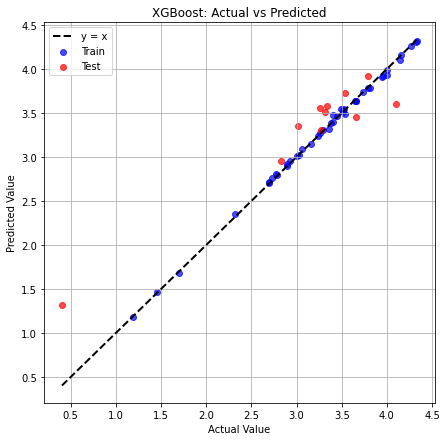

In [5]:
# Create and train XGBoost regressor
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Regression objective
    n_estimators=350,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train, y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test)
print("【test】: ", eval(y_test_pred, y_test))

plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import pandas as pd

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})

test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_grain2_log.csv', index=False)


In [8]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features_xgb, 'model/grain2_log_selected_features.pkl')

joblib.dump(model, 'model/grain2_log_xgb_model.pkl')

print("[Saved] model/grain2_log_selected_features.pkl")
print("[Saved] model/grain2_log_xgb_model.pkl")


[Saved] model/grain2_log_selected_features.pkl
[Saved] model/grain2_log_xgb_model.pkl


# 1.grain2 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

# 读取数据
data = pd.read_csv('data/compound_5_Structural_Grain2.csv')
data = data.drop(columns=['compound'])

X = data.iloc[:, :25].values  
y = data.iloc[:, 25:].values   


bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
y_bins = bins.fit_transform(y).ravel().astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins  
)

print('train data:', X_train.shape)
print('test data:', X_test.shape)
print('train target:', y_train.shape)
print('test target:', y_test.shape)


train data: (44, 25)
test data: (11, 25)
train target: (44, 1)
test target: (11, 1)


In [3]:
import os
import random
import numpy as np
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_absolute_error

SEED = 2024
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

USE_GPU = False  
def DEV_KW():
    ver = int(xgb.__version__.split('.')[0])
    if USE_GPU:
        return dict(device='cuda', predictor='gpu_predictor', tree_method='hist')
    else:
        return dict(tree_method='hist', predictor='auto')

NJOBS = 1

xgb_for_fs = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.06,
    max_depth=3,
    min_child_weight=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=10.0,
    gamma=0.0,
    importance_type='gain',
    n_jobs=NJOBS,
    random_state=SEED,
    **DEV_KW()
)

selector = RFECV(
    estimator=xgb_for_fs,
    step=2,
    cv=3,
    scoring='neg_root_mean_squared_error',
    min_features_to_select=3,
    n_jobs=NJOBS
)
selector.fit(X_train, y_train.ravel())

selected_idx = np.where(selector.support_)[0]

MAX_FEATS = 6
if selected_idx.size > MAX_FEATS:
    xgb_quick = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=400,
        learning_rate=0.06,
        max_depth=3,
        min_child_weight=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10.0,
        gamma=0.0,
        importance_type='gain',
        n_jobs=NJOBS,
        random_state=SEED,
        **DEV_KW()
    )
    xgb_quick.fit(X_train, y_train.ravel(), verbose=False)
    importances_in_sel = xgb_quick.feature_importances_[selected_idx]
    topk_rel = np.argsort(importances_in_sel)[::-1][:MAX_FEATS]
    selected_idx = np.sort(selected_idx[topk_rel])


X_train_sel = X_train[:, selected_idx].astype(np.float32, copy=False)
X_test_sel  = X_test[:,  selected_idx].astype(np.float32,  copy=False)
print("number：", X_train_sel.shape[1])

number： 6


XGBoost_debug train: 
 r2: 0.7968167863293061  rmse: 7.888457124612194  mse:62.22775580684488 error_ratio:31.5% mae:6.013797808777201
XGBoost_debug test: 
 r2: 0.7482902679870183  rmse: 9.429454460089184 mse:88.91461141489582 error_ratio:32.05% mae:7.170670413970948
save result successful！


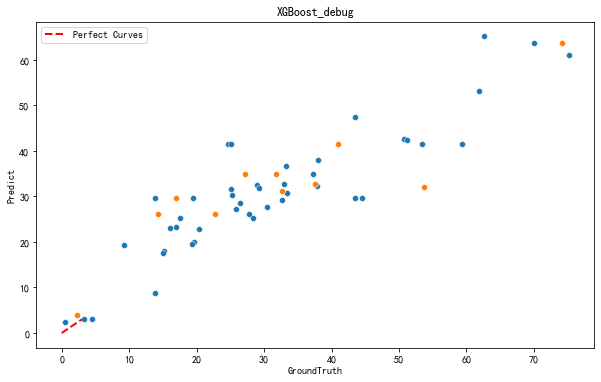

n_features_in_ (model expects): 6
X_train_sel.shape[1]: 6


In [4]:
from utils import eval, visual, save, save_model
from model import Model
from sklearn.model_selection import KFold, cross_validate
import numpy as np

XGBoost_model = XGBRegressor(
    n_estimators=800,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=8,
    min_child_weight=4,
    gamma=0.0
)

model = Model(XGBoost_model, X_train_sel, X_test_sel, y_train, y_test, 'XGBoost_debug', '5_grain2')
visual(model, 'XGBoost_debug', X_train_sel, X_test_sel, y_train, y_test)

base = None
for attr in ("model", "estimator", "clf", "reg", "model_"):
    if hasattr(model, attr):
        base = getattr(model, attr)
        break

if base is None:
    XGBoost_model.fit(X_train_sel, np.asarray(y_train).ravel())
    base = XGBoost_model

y_train_pred = base.predict(X_train_sel)
y_test_pred  = base.predict(X_test_sel)

y_train_1d = np.asarray(y_train).ravel()
y_test_1d  = np.asarray(y_test).ravel()
y_train_pred_1d = np.asarray(y_train_pred).ravel()
y_test_pred_1d  = np.asarray(y_test_pred).ravel()

print("n_features_in_ (model expects):", getattr(base, "n_features_in_", None))
print("X_train_sel.shape[1]:", X_train_sel.shape[1])


In [5]:
import os, pandas as pd
os.makedirs('result', exist_ok=True)

train_df = pd.DataFrame({
    'Actual':   y_train_1d,
    'Predicted': y_train_pred_1d
})
test_df = pd.DataFrame({
    'Actual':   y_test_1d,
    'Predicted': y_test_pred_1d
})

train_df['Set'] = 'Train'
test_df['Set']  = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)
all_df.to_csv('result/XGBoost_grain2.csv', index=False)


In [8]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

selector_ct = ColumnTransformer([("sel", "passthrough", selected_idx)], remainder="drop")

pipe = Pipeline([
    ("select", selector_ct),
    ("reg", XGBoost_model)  
])

joblib.dump(pipe, 'model/grain2_pipeline.pkl')
print("[Saved] model/grain2_pipeline.pkl")


[Saved] model/grain2_pipeline.pkl


# 2. a_2

In [3]:
data = pd.read_csv('data/compound_5_Structural_a2.csv').drop(columns=['compound'])
target_col = 'a_2'
X, y = data.drop(columns=[target_col]), data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
fs_est = XGBRegressor(
    n_estimators=200, random_state=42, verbosity=0, tree_method='hist'
)
fs_est.fit(X_train, y_train)

importances = fs_est.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'imp': importances}) \
           .sort_values('imp', ascending=False)
selected_features = feat_df.head(6)['feature'].tolist()

print("number:", len(selected_features))
print("features:", selected_features)

number: 6
features: ['feat_21', 'feat_8', 'feat_5', 'feat_13', 'feat_7', 'feat_10']


5CV:
MSE: 1.3807 ± 0.6587
RMSE: 1.1440 ± 0.2681
MAE: 0.8894 ± 0.1808
R2: 0.6557 ± 0.1994


【train】:  MSE: 0.1243  RMSE: 0.3525  MAE: 0.2637, R2: 0.9745
【test】:  MSE: 0.7177  RMSE: 0.8472  MAE: 0.6620, R2: 0.8597


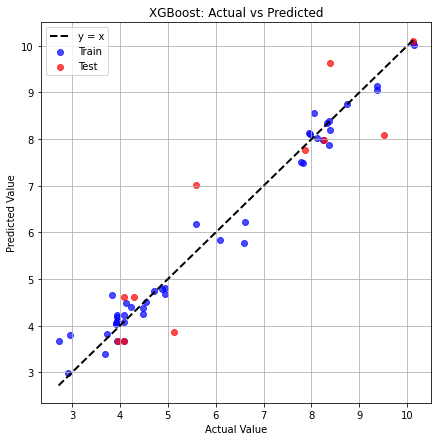

In [6]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Regression objective
    n_estimators=200,
    max_depth=6,
    learning_rate=0.15,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=6,
    reg_alpha=0.1,
    reg_lambda=5,
    subsample=0.75,
    random_state=42
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train[selected_features], y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train[selected_features], y_train)

y_train_pred = model.predict(X_train[selected_features])
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test[selected_features])
print("【test】: ", eval(y_test_pred, y_test))

#figure
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
import os
import pandas as pd

os.makedirs('result', exist_ok=True)

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_a2.csv', index=False)


In [11]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features, 'model/a2_selected_features.pkl')

joblib.dump(model, 'model/a2_xgb_model.pkl')

print("[Saved] model/a2_selected_features.pkl")
print("[Saved] model/a2_xgb_model.pkl")


[Saved] model/a2_selected_features.pkl
[Saved] model/a2_xgb_model.pkl


# 3.b2

In [2]:
data = pd.read_csv('data/compound_5_Structural_b2.csv').drop(columns=['compound'])
target_col = 'b_2'
X, y = data.drop(columns=[target_col]), data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
fs_est = XGBRegressor(
    n_estimators=200, random_state=42, verbosity=0, tree_method='hist'
)
fs_est.fit(X_train, y_train)

importances = fs_est.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'imp': importances}) \
           .sort_values('imp', ascending=False)
selected_features = feat_df.head(9)['feature'].tolist()

print("number:", len(selected_features))
print("features:", selected_features)

number: 9
features: ['feat_21', 'feat_8', 'feat_10', 'feat_5', 'feat_9', 'feat_11', 'feat_7', 'feat_6', 'feat_13']


5CV:
MSE: 1.4373 ± 1.1813
RMSE: 1.1086 ± 0.4564
MAE: 0.8302 ± 0.2945
R2: 0.6727 ± 0.2095


【train】:  MSE: 0.2479  RMSE: 0.4979  MAE: 0.3709, R2: 0.9478
【test】:  MSE: 0.4675  RMSE: 0.6838  MAE: 0.5755, R2: 0.9086


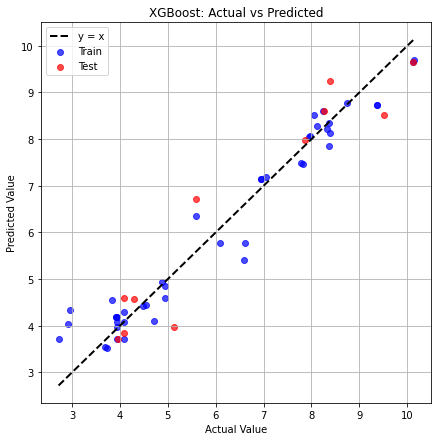

In [4]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Regression objective
    n_estimators=100,
    max_depth=2,
    learning_rate=0.15,
    colsample_bytree=0.7,
    gamma=0.5,
    min_child_weight=6,
    reg_alpha=0.1,
    reg_lambda=5,
    subsample=0.75,
    random_state=42
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train[selected_features], y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train[selected_features], y_train)

y_train_pred = model.predict(X_train[selected_features])
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test[selected_features])
print("【test】: ", eval(y_test_pred, y_test))

#figure
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import pandas as pd

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})

test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_b2.csv', index=False)

In [6]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features, 'model/b2_selected_features.pkl')

joblib.dump(model, 'model/b2_xgb_model.pkl')

print("[Saved] model/b2_selected_features.pkl")
print("[Saved] model/b2_xgb_model.pkl")


[Saved] model/b2_selected_features.pkl
[Saved] model/b2_xgb_model.pkl


# 4. c2

In [7]:
data = pd.read_csv('data/compound_5_Structural_c2.csv')
data = data.drop(columns=["compound"])
target_col = "c_2"

X = data.drop(columns=[target_col])
y = data[target_col]
# y = np.log1p(y)

In [8]:
data = pd.read_csv('data/compound_5_Structural_c2.csv').drop(columns=['compound'])
target_col = 'c_2'
X, y = data.drop(columns=[target_col]), data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
fs_est = XGBRegressor(
    n_estimators=200, random_state=42, verbosity=0, tree_method='hist'
)
fs_est.fit(X_train, y_train)

importances = fs_est.feature_importances_
feat_df = pd.DataFrame({'feature': X_train.columns, 'imp': importances}) \
           .sort_values('imp', ascending=False)
selected_features = feat_df.head(10)['feature'].tolist()

print("number:", len(selected_features))
print("features:", selected_features)

number: 10
features: ['feat_8', 'feat_9', 'feat_11', 'feat_12', 'feat_7', 'feat_10', 'feat_3', 'feat_1', 'feat_5', 'feat_13']


5CV:
MSE: 10.0790 ± 5.6242
RMSE: 3.0290 ± 0.9509
MAE: 2.1476 ± 0.6185
R2: -0.1880 ± 0.7402


【train】:  MSE: 0.9980  RMSE: 0.9990  MAE: 0.5843, R2: 0.9161
【test】:  MSE: 0.6092  RMSE: 0.7805  MAE: 0.6608, R2: 0.8385


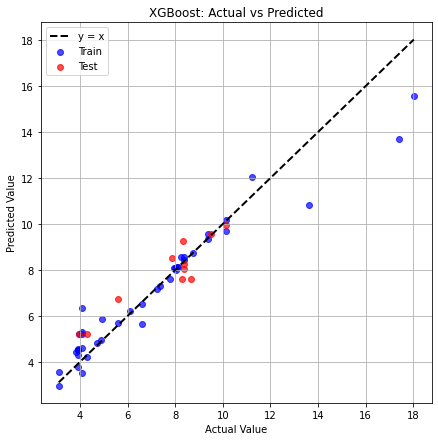

In [11]:
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,        
    learning_rate=0.06,     
    max_depth=3,             
    min_child_weight=6,      
    gamma=0.1,               
    subsample=0.75,         
    colsample_bytree=0.65,  
    reg_alpha=0.3,           
    reg_lambda=10.0,         
    random_state=24,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)

def eval(y_pred, y):
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return f"MSE: {mse:.4f}  RMSE: {rmse:.4f}  MAE: {mae:.4f}, R2: {r2:.4f}"

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2'
}

print("5CV:")
cv_results = cross_validate(model, X_train[selected_features], y_train, cv=kf, scoring=scoring, return_train_score=False)

print(f"MSE: {-cv_results['test_MSE'].mean():.4f} ± {cv_results['test_MSE'].std():.4f}")
print(f"RMSE: {-cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")
print(f"MAE: {-cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"R2: {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")

print("\n" + "="*60 + "\n")

# Fit the model
model.fit(X_train[selected_features], y_train)

y_train_pred = model.predict(X_train[selected_features])
print("【train】: ", eval(y_train_pred, y_train))

y_test_pred = model.predict(X_test[selected_features])
print("【test】: ", eval(y_test_pred, y_test))

#figure
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.7)

plt.scatter(y_test, y_test_pred, color='red', label='Test', alpha=0.7)

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='y = x')

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('XGBoost: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
import os
import pandas as pd

os.makedirs('result', exist_ok=True)

train_df = pd.DataFrame({
    'Actual': y_train,
    'Predicted': y_train_pred
})
test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred
})

train_df['Set'] = 'Train'
test_df['Set'] = 'Test'

all_df = pd.concat([train_df, test_df], ignore_index=True)

all_df.to_csv('result/XGBoost_c2.csv', index=False)


In [13]:
import os, joblib

os.makedirs('model', exist_ok=True)

joblib.dump(selected_features, 'model/c2_selected_features.pkl')

joblib.dump(model, 'model/c2_xgb_model.pkl')

print("[Saved] model/c2_selected_features.pkl")
print("[Saved] model/c2_xgb_model.pkl")


[Saved] model/c2_selected_features.pkl
[Saved] model/c2_xgb_model.pkl
